In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import torch
from IPython.display import Image
import shutil
import os
from random import choice

In [ ]:
!git clone https://github.com/ultralytics/yolov5 #https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 16052, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 16052 (delta 50), reused 54 (delta 27), pack-reused 15967
Receiving objects: 100% (16052/16052), 14.69 MiB | 36.08 MiB/s, done.
Resolving deltas: 100% (11016/11016), done.


In [ ]:
%cd /content/yolov5/

/content/yolov5


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.6/190.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 55.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.2/645.2 kB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.3 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 9.4.0
    Uninstalling Pillow-9.4.0:
      Successfully uninstalled Pillow-9.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imageio 2.31.6 requires pillow<10.1.0,>=8.3.2, but you have pillow 10.1.0 which is incompatible.


In [ ]:
# arrays to store file names
imgs = []
xmls = []

# setup directory names
train_path = "/content/drive/MyDrive/20/yolo/train/images"
val_path = "/content/drive/MyDrive/20/yolo/valid/images"
crs_path = "/content/drive/MyDrive/20/yolo/images"

train_ratio = 0.8
val_ratio = 0.2

# total count of imgs
total_img_count = len(os.listdir(crs_path))/2

# sorting count of imgs
for (dirname,dirs, files) in os.walk(crs_path):
#     print(files)
    for filename in files:
#         print("hello")
        if filename.endswith(".txt"):
            xmls.append(filename)
        else:
            imgs.append(filename)

# counting range for cycles
count_for_train = int(len(imgs)*train_ratio)
count_for_val = int(len(imgs)*val_ratio)
print("training images are : ",count_for_train)
print("validation images are : ",count_for_val)

training images are :  48
validation images are :  12


In [ ]:
len(imgs)

60

In [ ]:
train_image_path = "/content/drive/MyDrive/20/yolo/train/images"
train_label_path = "/content/drive/MyDrive/20/yolo/train/labels"
val_image_path = "/content/drive/MyDrive/20/yolo/valid/images"
val_label_path = "/content/drive/MyDrive/20/yolo/valid/labels"

if not os.path.isdir(train_image_path):
    os.makedirs(train_image_path)
if not os.path.isdir(train_label_path):
    os.makedirs(train_label_path)
if not os.path.isdir(val_image_path):
    os.makedirs(val_image_path)
if not os.path.isdir(val_label_path):
    os.makedirs(val_label_path)

# cycle for train dir
for x in range(count_for_train):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(train_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(train_label_path,file_xml))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

# cycle for test dir
for x in range(count_for_val):
    file_jpg = choice(imgs)
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(val_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(val_label_path,file_xml))

    imgs.remove(file_jpg)
    xmls.remove(file_xml)

# rest of files
print("images length - ",len(imgs))
print(imgs,xmls)
for x in imgs:
    file_jpg = x
    file_xml = file_jpg[:-4] + ".txt"

    shutil.copy(os.path.join(crs_path,file_jpg),os.path.join(val_image_path,file_jpg))
    shutil.copy(os.path.join(crs_path,file_xml),os.path.join(val_label_path,file_xml))
# shutil.copytree(crs_path,val_path)

images length -  0
[] []


In [ ]:
with open(r'/content/drive/MyDrive/20/yolo/data.yaml', 'r') as file:
    lines = file.readlines()
    print(lines)

['train: /content/drive/MyDrive/20/yolo/train/images\n', 'val: /content/drive/MyDrive/20/yolo/valid/images\n', '\n', '\n', 'nc: 3\n', "names: ['benign', 'malignant', 'normal']\n", '\n', 'roboflow:\n', '  workspace: tru-projects-7dbwp\n', '  project: lung-cancer-detection-ikypr\n', '  version: 1\n', '  license: CC BY 4.0\n', '  url: https://universe.roboflow.com/tru-projects-7dbwp/lung-cancer-detection-ikypr/dataset/1']


In [26]:
ML_Model = []
precision = []
recall = []
mAP = []

#function to call for storing the results
def storeResults(model, a,b,c):
    ML_Model.append(model)
    precision.append(round(a, 3))
    recall.append(round(b, 3))
    mAP.append(round(c, 3))

# Yolov 5x6

In [ ]:
!wandb disabled
!python train.py --img 416 --batch 2 --epochs 200 --data /content/drive/MyDrive/20/yolo/data.yaml --weights yolov5x6.pt --cache --workers 2

/bin/bash: line 1: wandb: command not found
2023-11-06 04:12:06.902852: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-06 04:12:06.902902: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-11-06 04:12:06.902952: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5x6.pt, cfg=, data=/content/drive/MyDrive/20/yolo/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=200, batch_size=2, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=F

In [22]:
p_yol5 = 0.94
r_yol5 = 0.99
mAP_yolo5 = 0.99

In [36]:
storeResults('YoloV5',p_yol5,r_yol5,mAP_yolo5)

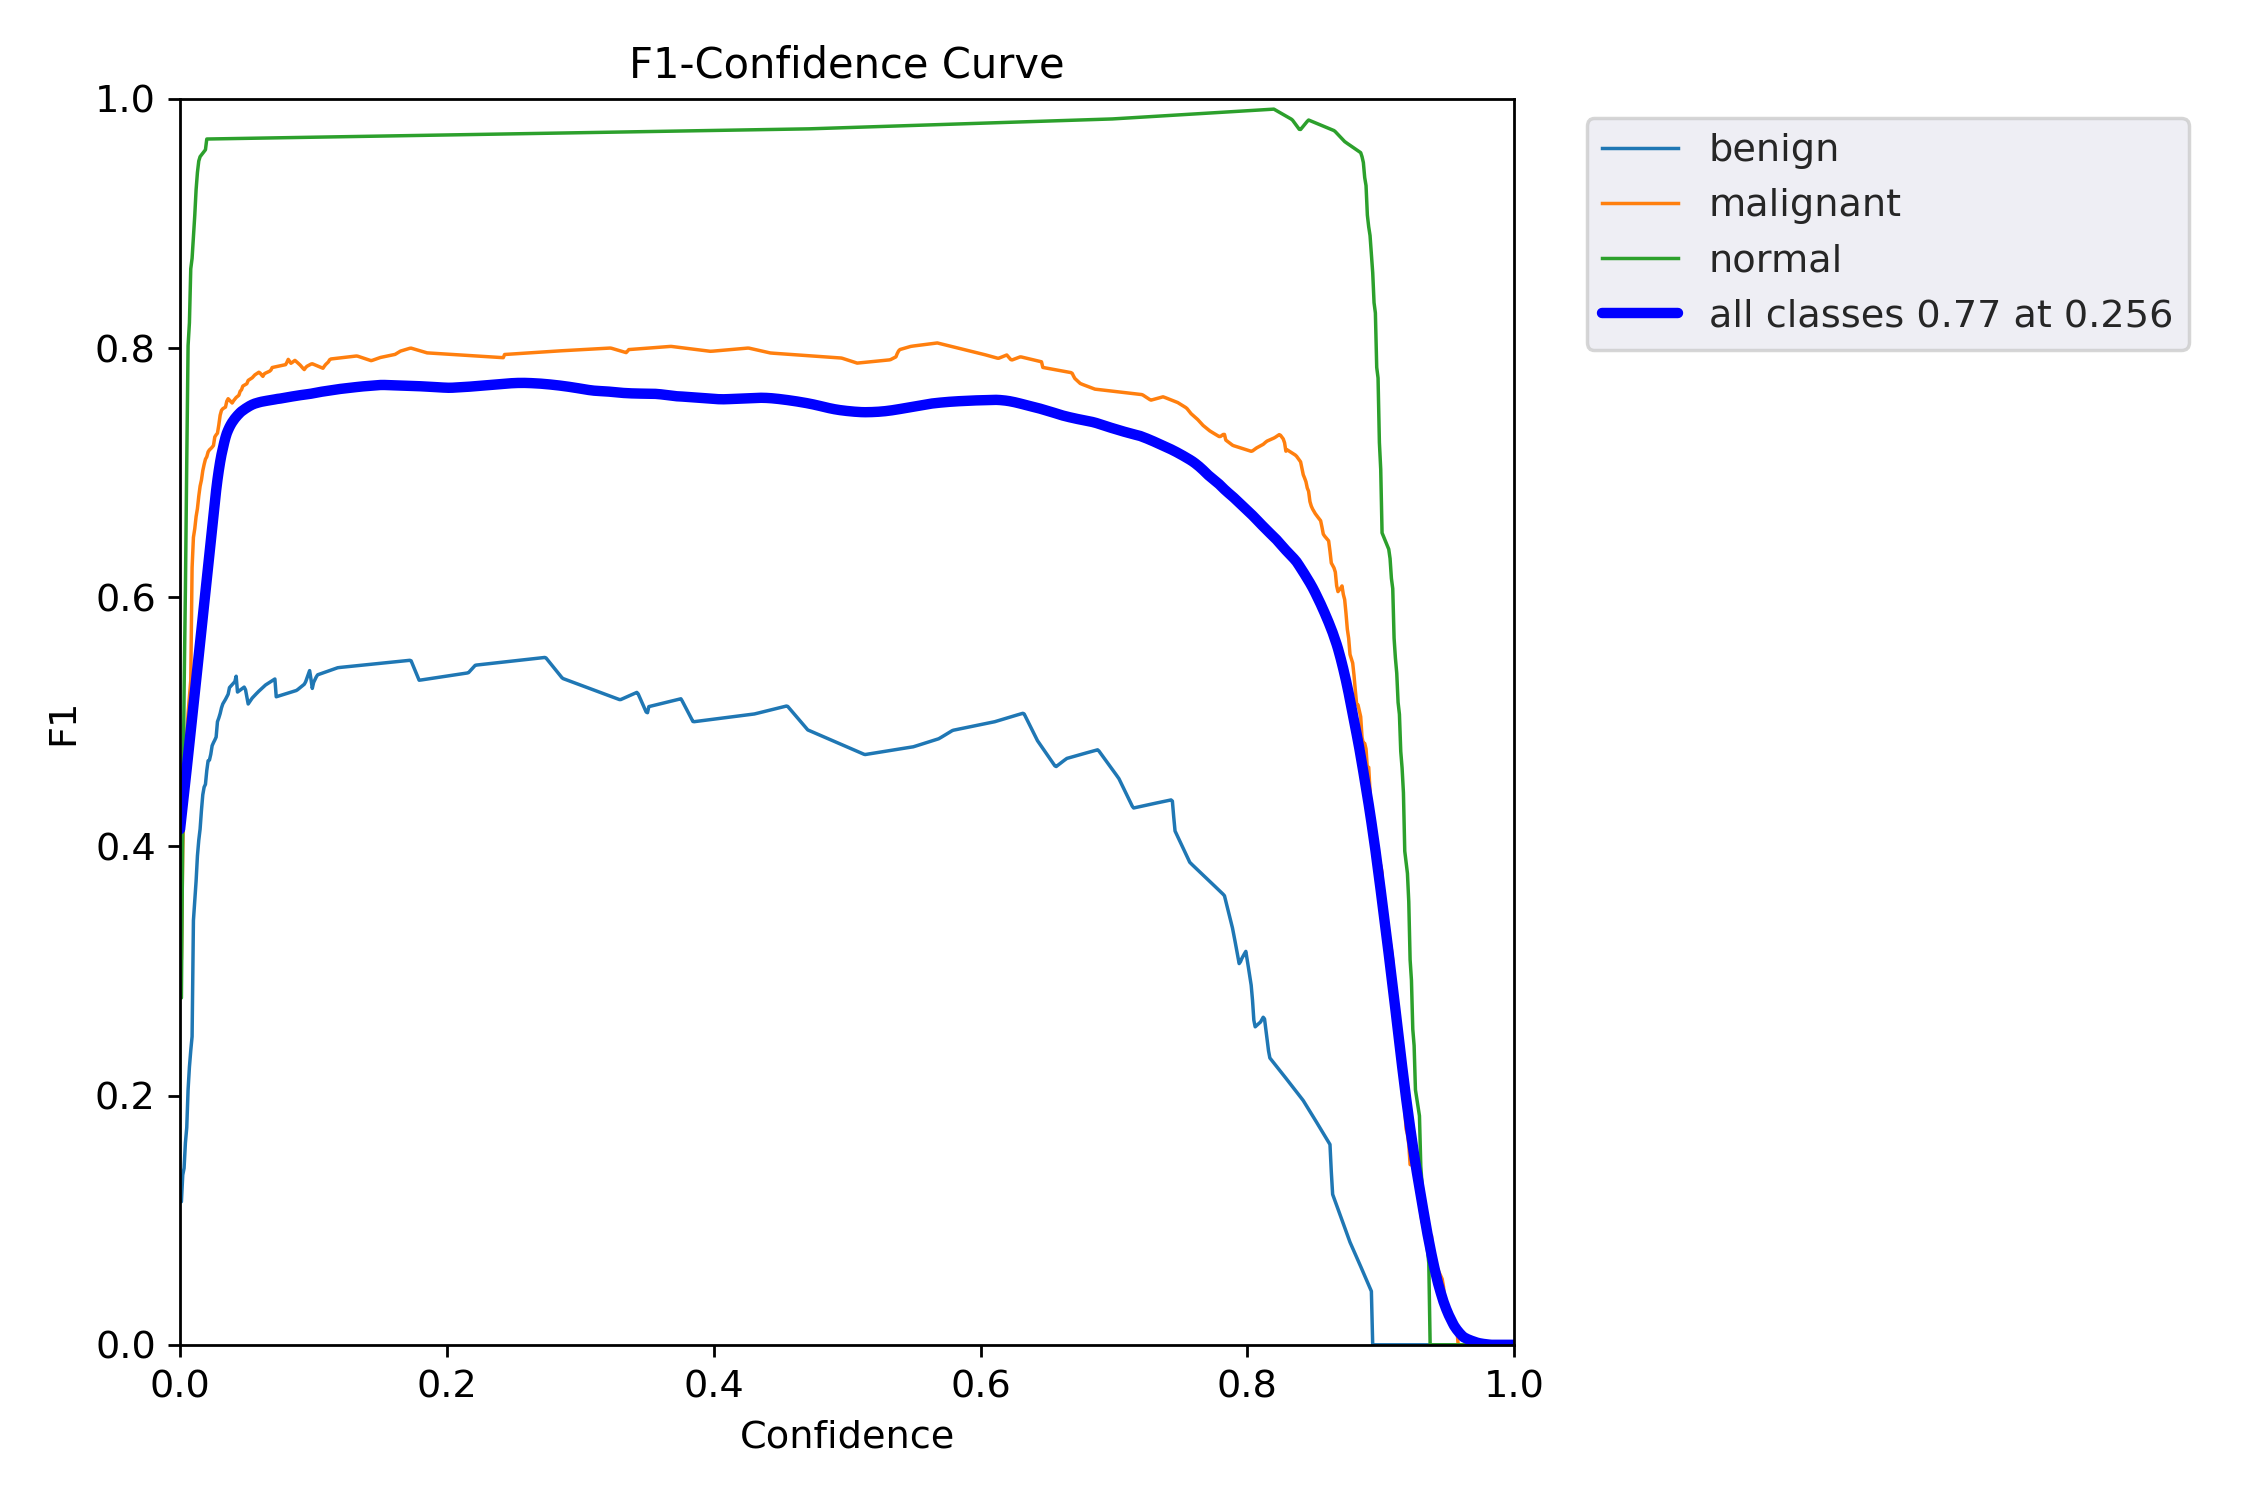

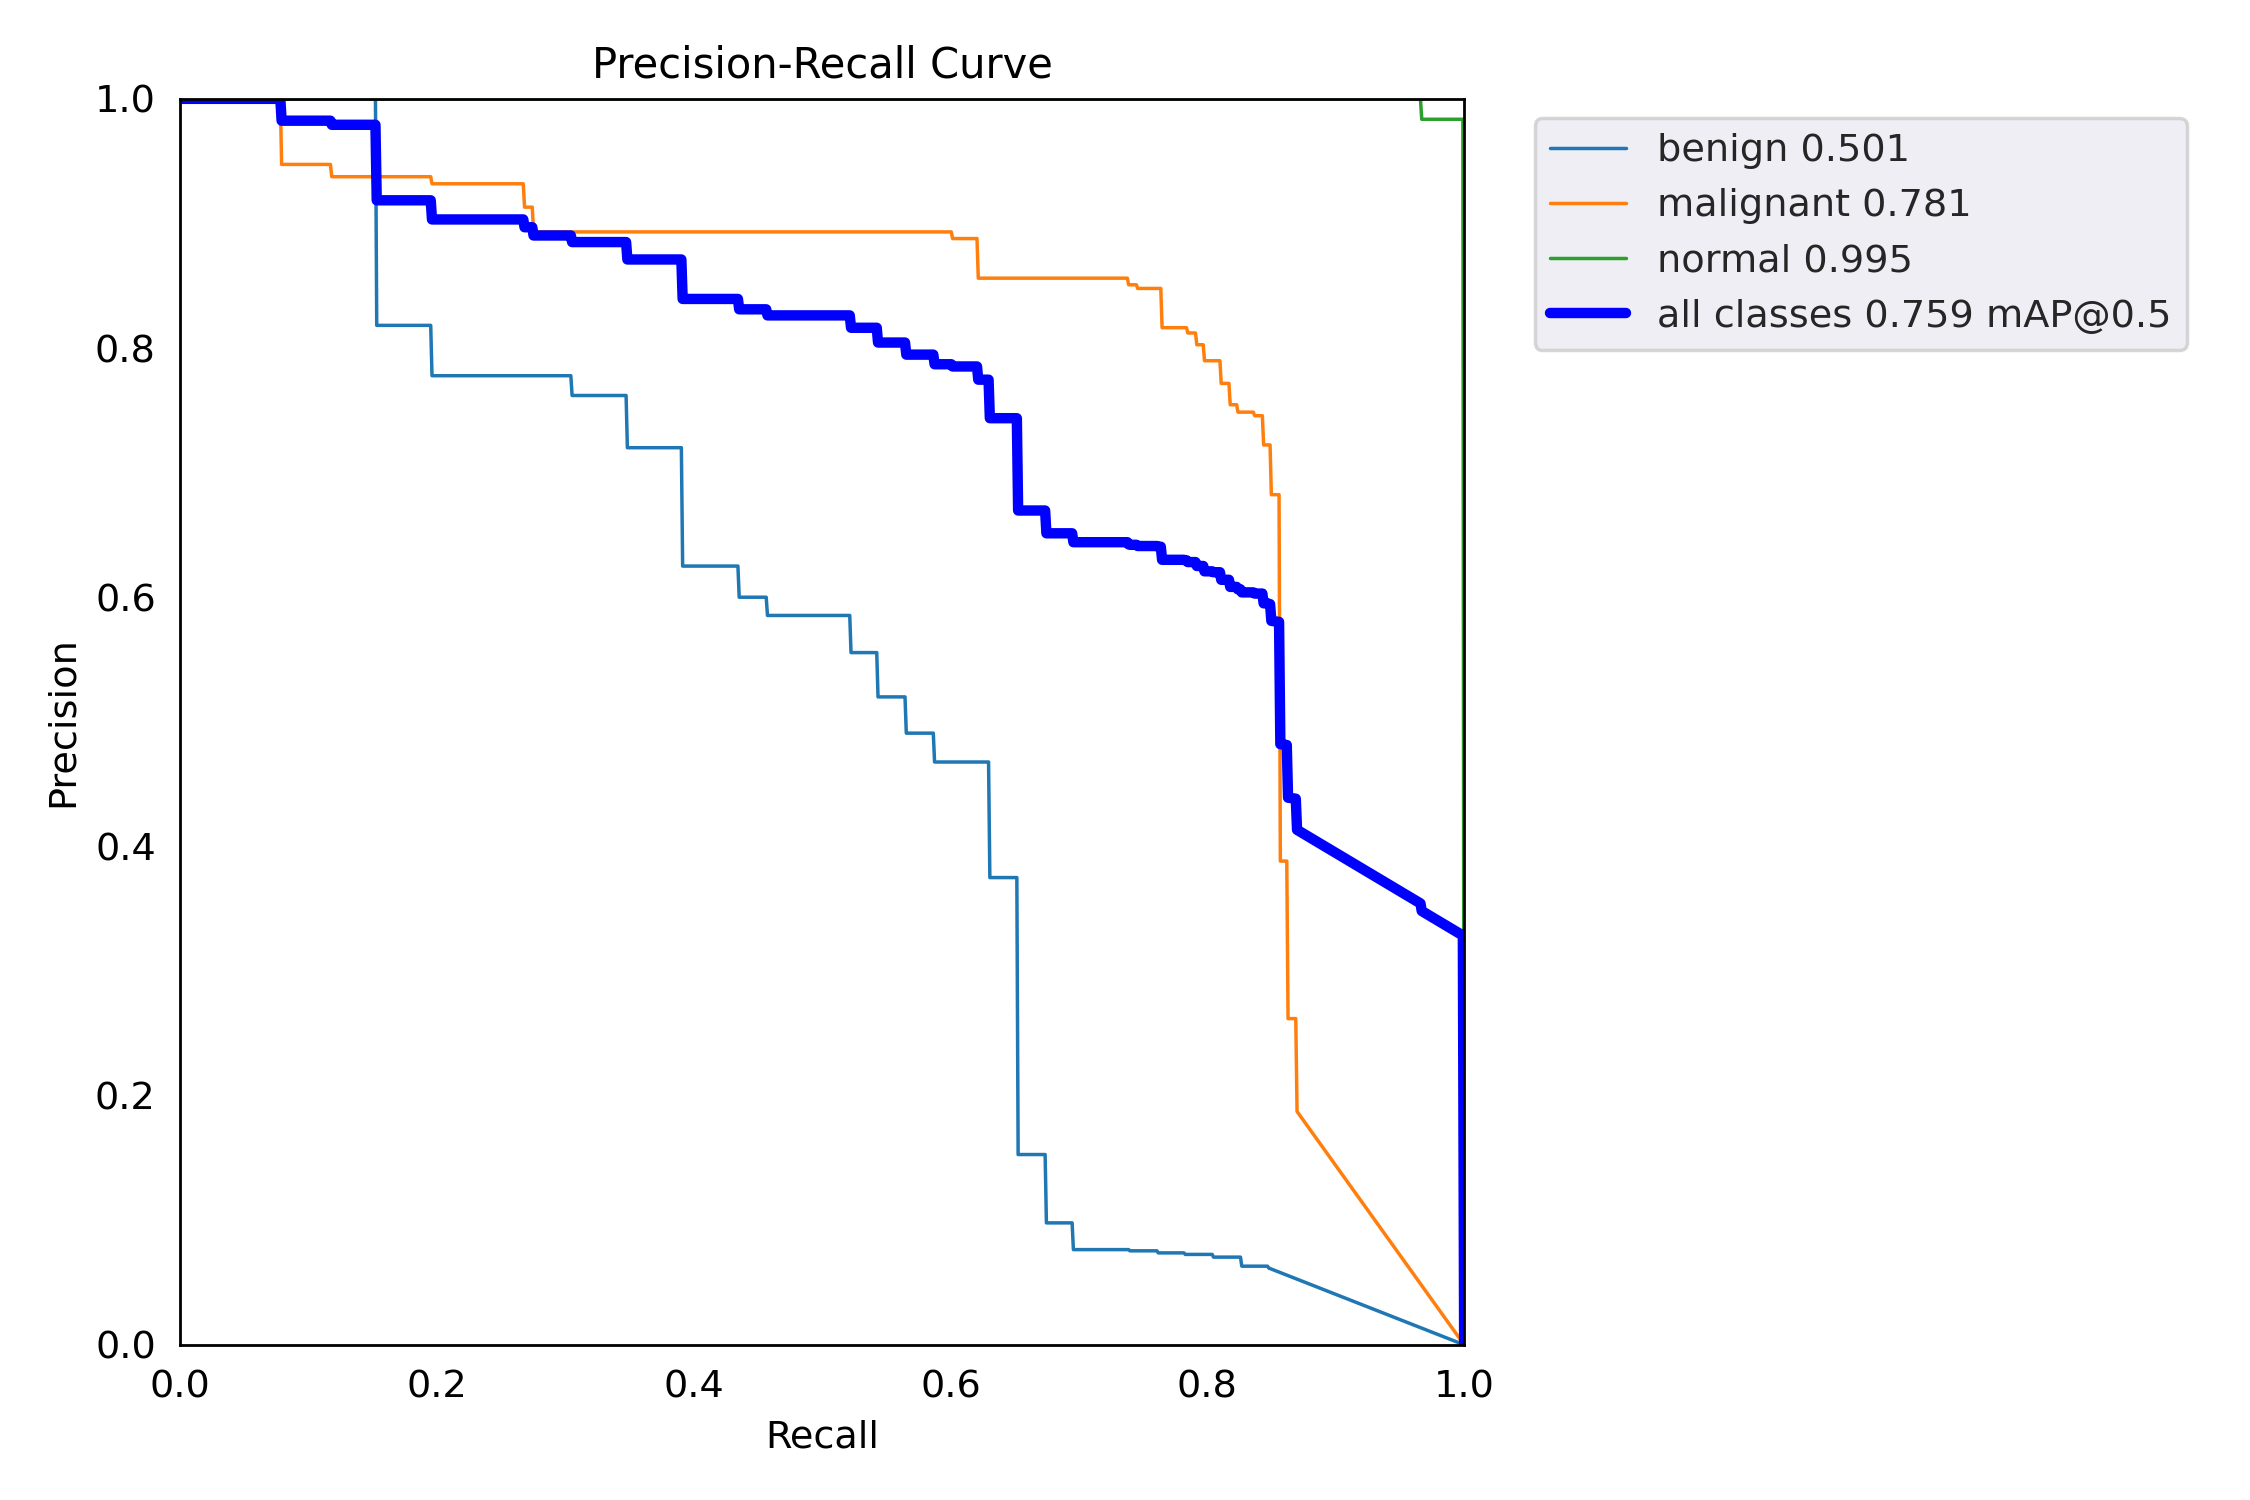

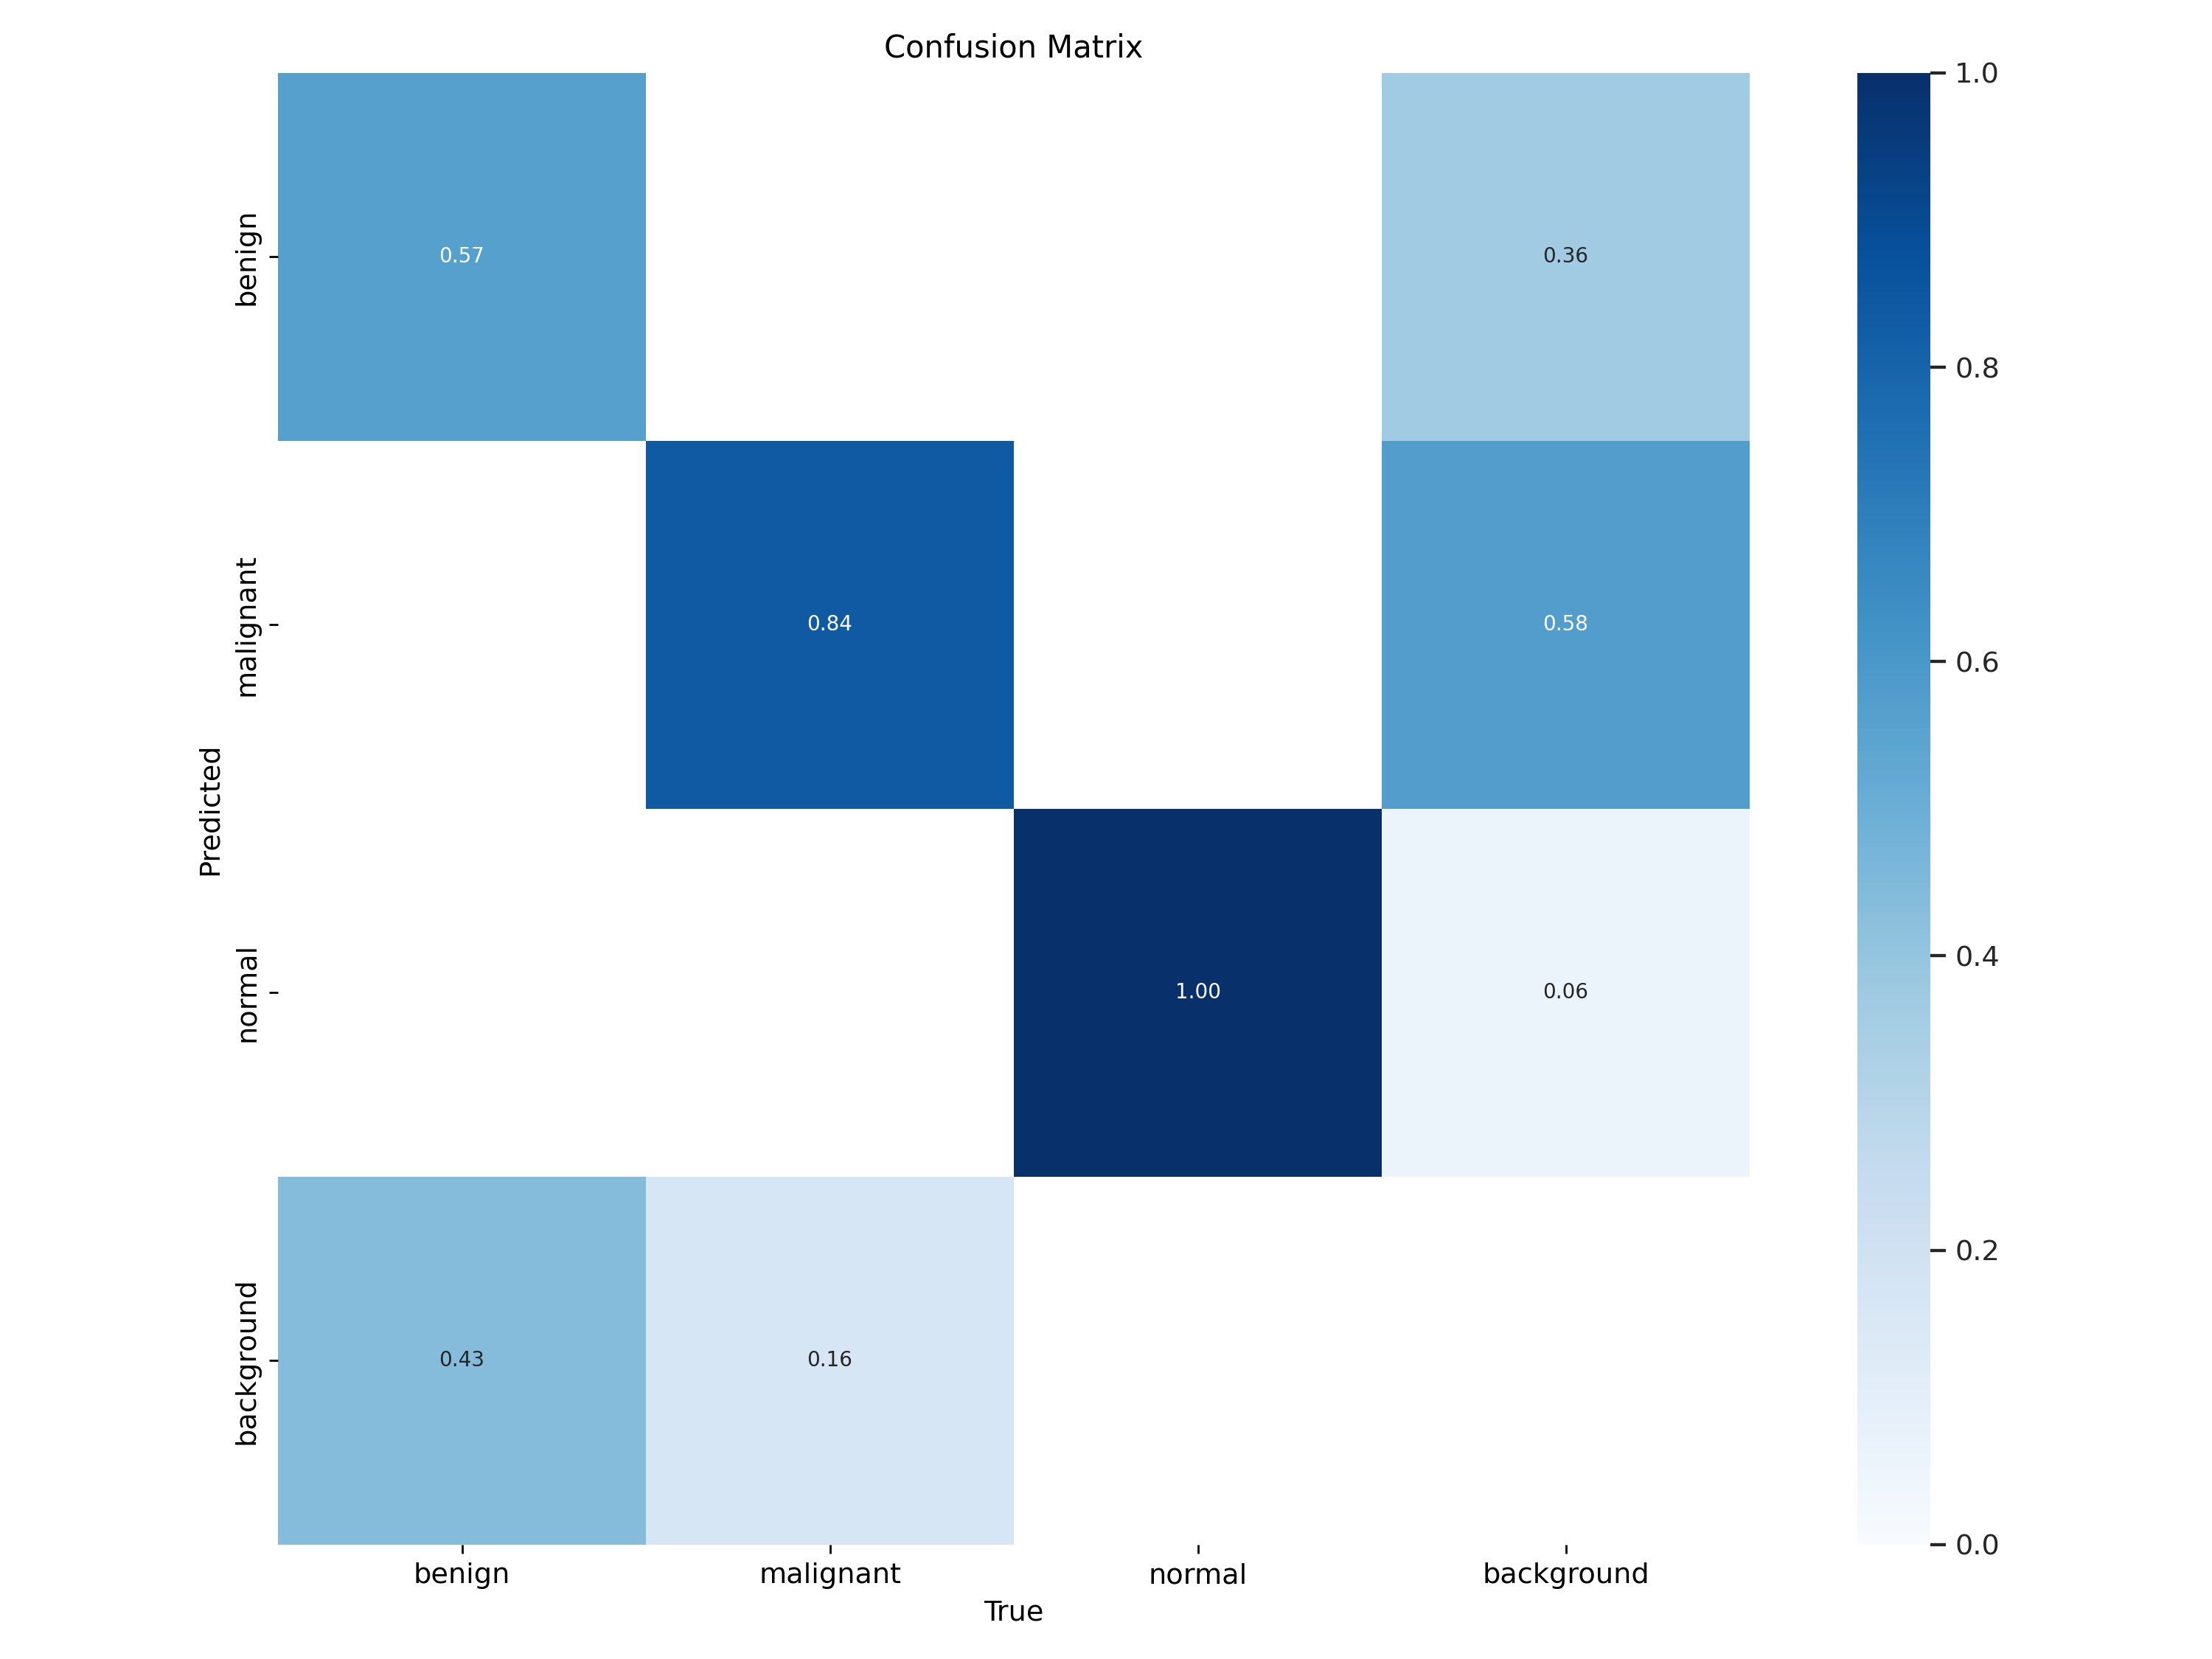

In [ ]:
# dislaying metrics for train data
from IPython.display import Image
from IPython.display import display
x = Image(filename='runs/train/exp/F1_curve.png')
y = Image(filename='runs/train/exp/PR_curve.png')
z = Image(filename='runs/train/exp/confusion_matrix.png')
display(x, y,z)

In [ ]:
!zip -r /content/drive/MyDrive/20/file.zip /content/yolov5

updating: content/yolov5/ (stored 0%)
updating: content/yolov5/.gitignore (deflated 55%)
updating: content/yolov5/CONTRIBUTING.md (deflated 56%)
updating: content/yolov5/runs/ (stored 0%)
updating: content/yolov5/runs/train/ (stored 0%)
updating: content/yolov5/runs/train/exp/ (stored 0%)
updating: content/yolov5/runs/train/exp/val_batch2_labels.jpg (deflated 11%)
updating: content/yolov5/runs/train/exp/val_batch0_labels.jpg (deflated 17%)
updating: content/yolov5/runs/train/exp/val_batch0_pred.jpg (deflated 17%)
updating: content/yolov5/runs/train/exp/R_curve.png (deflated 11%)
updating: content/yolov5/runs/train/exp/opt.yaml (deflated 48%)
updating: content/yolov5/runs/train/exp/val_batch2_pred.jpg (deflated 11%)
updating: content/yolov5/runs/train/exp/train_batch0.jpg (deflated 14%)
updating: content/yolov5/runs/train/exp/hyp.yaml (deflated 45%)
updating: content/yolov5/runs/train/exp/train_batch1.jpg (deflated 11%)
updating: content/yolov5/runs/train/exp/F1_curve.png (deflated 11%)

YoloV8n

In [3]:
%cd /content

/content


In [4]:
!pip install ultralytics

In [5]:
# check the uploaded data in drive
!ls '/content/drive/MyDrive/20/yolov8'
!ls '/content/drive/MyDrive/20/yolov8/train/'

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
images	labels


In [6]:
# Checking the size of images and displaying them
import numpy as np
import cv2
# Image shape in Training
image = cv2.imread('/content/drive/MyDrive/20/yolov8/test/images/Bengin-case-103-_jpg.rf.cec517a8109c0b7e2ad85bb90aa97902.jpg')
height = np.size(image, 0)
width = np.size(image, 1)
print ("shape of the training image {}, {}".format(height, width))
# Image shape in validation
image = cv2.imread('/content/drive/MyDrive/20/yolov8/test/images/Normal-case-237-_jpg.rf.c62a77fae09d10f408c34aa02715d72e.jpg')
height = np.size(image, 0)
width = np.size(image, 1)
print ("shape of the validation image {}, {}".format(height, width))

shape of the training image 640, 640
shape of the validation image 640, 640


In [7]:
from ultralytics import YOLO

# Load a model
# model = YOLO("yolov8m.yaml")  # build a new model from scratch
model = YOLO("yolov8m.pt")  # load a pretrained model (recommended for training)

# Use the model
results = model.train(data="/content/drive/MyDrive/20/yolov8/data.yaml", epochs=200, imgsz=415)  # train the model

Ultralytics YOLOv8.0.207 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/20/yolov8/data.yaml, epochs=200, patience=50, batch=16, imgsz=415, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchscript,

In [23]:
p_yol8 = 0.645
r_yol8 = 0.663
mAP_yolo8 = 0.628

In [37]:
storeResults('YoloV8',p_yol8,r_yol8,mAP_yolo8)

# FasterRCNN

In [3]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from engine import train_one_epoch, evaluate
import utils
import transforms as T
import albumentations as A
import cv2
import time
from albumentations.pytorch.transforms import ToTensorV2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from  sklearn.model_selection import KFold
import random

In [4]:
class CraterDataset(object):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(self.root, "images"))))
        self.annots = list(sorted(os.listdir(os.path.join(self.root, "labels"))))
        self.classes = ['benign', 'malignant', 'normal']

    # Converts boundry box formats, this version assumes single class only!
    def convert_box_cord(self,bboxs, format_from, format_to, img_shape):
        if format_from == 'normxywh':
            if format_to == 'xyminmax':
                xw = bboxs[:, (1, 3)] * img_shape[1]
                yh = bboxs[:, (2, 4)] * img_shape[0]
                xmin = xw[:, 0] - xw[:, 1] / 2
                xmax = xw[:, 0] + xw[:, 1] / 2
                ymin = yh[:, 0] - yh[:, 1] / 2
                ymax = yh[:, 0] + yh[:, 1] / 2
                coords_converted = np.column_stack((xmin, ymin, xmax, ymax))

        return coords_converted

    def __getitem__(self, idx):
        # load images and boxes
        img_path = os.path.join(self.root, "images", self.imgs[idx])
        annot_path = os.path.join(self.root, "labels", self.annots[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img= img/255.0

        # retrieve bbox list and format to required type,
        # if annotation file is empty, fill dummy box with label 0
        if os.path.getsize(annot_path) != 0:
            bboxs = np.loadtxt(annot_path, ndmin=2)
            bboxs = self.convert_box_cord(bboxs, 'normxywh', 'xyminmax', img.shape)
            num_objs = len(bboxs)
            bboxs = torch.as_tensor(bboxs, dtype=torch.float32)
            # there is only one class
            labels = torch.ones((num_objs,), dtype=torch.int64)
            # suppose all instances are not crowd
            iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
        else:
            bboxs = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            labels = torch.zeros((1,), dtype=torch.int64)
            iscrowd = torch.zeros((1,), dtype=torch.int64)

        area = (bboxs[:, 3] - bboxs[:, 1]) * (bboxs[:, 2] - bboxs[:, 0])
        image_id = torch.tensor([idx])

        target = {}
        target["boxes"] = bboxs
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            sample = self.transforms(image=img,
                                     bboxes=target['boxes'],
                                     labels=labels)
        img = sample['image']
        target['boxes'] = torch.tensor(sample['bboxes'])
        target['labels'] = torch.tensor(sample['labels'])
        if target['boxes'].ndim == 1:
            target['boxes'] = torch.as_tensor([[0, 0, 640, 640]], dtype=torch.float32)
            target['labels'] = torch.zeros((1,), dtype=torch.int64)
        return img, target

    def __len__(self):
        return len(self.imgs)

In [5]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [6]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [7]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [8]:
def plot_img_bbox(img, target):
    # plot the image and bboxes
    # Bounding boxes are defined as follows: x-min y-min width height
    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img.permute((1,2,0)))
    for box in (target['boxes']):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 edgecolor='b',
                                 facecolor='none',
                                 clip_on=False)
        a.annotate('cancer', (x,y-20), color='blue', weight='bold',
                   fontsize=10, ha='left', va='top')

        # Draw the bounding box on top of the image
        a.add_patch(rect)
    plt.show()

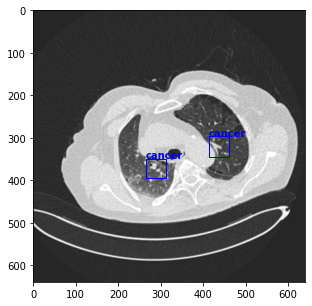

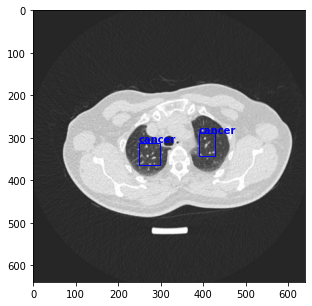

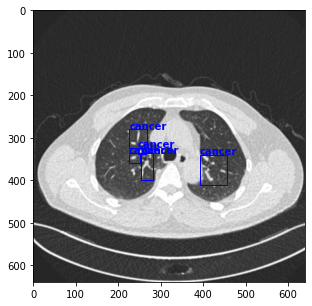

In [9]:
dataset = CraterDataset('yolo/train/', get_transform(train=True))
# Prints an example of image with annotations
for i in random.sample(range(1, 100), 3):
    img, target = dataset[i]
    plot_img_bbox(img, target)

In [10]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [12]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 3
# use our dataset and defined transformations
dataset = CraterDataset('yolo/train', get_transform(train=True))
dataset_test = CraterDataset('yolo/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/53]  eta: 0:21:16  lr: 0.000950  loss: 1.7079 (1.7079)  loss_classifier: 1.3173 (1.3173)  loss_box_reg: 0.1295 (0.1295)  loss_objectness: 0.2409 (0.2409)  loss_rpn_box_reg: 0.0202 (0.0202)  time: 24.0865  data: 0.0980
Epoch: [0]  [50/53]  eta: 0:01:09  lr: 0.005000  loss: 0.3550 (0.4394)  loss_classifier: 0.1291 (0.2113)  loss_box_reg: 0.1798 (0.1621)  loss_objectness: 0.0219 (0.0544)  loss_rpn_box_reg: 0.0084 (0.0115)  time: 23.1562  data: 0.0836
Epoch: [0]  [52/53]  eta: 0:00:23  lr: 0.005000  loss: 0.3550 (0.4360)  loss_classifier: 0.1291 (0.2084)  loss_box_reg: 0.1820 (0.1629)  loss_objectness: 0.0226 (0.0532)  loss_rpn_box_reg: 0.0084 (0.0114)  time: 22.6854  data: 0.0838
Epoch: [0] Total time: 0:20:25 (23.1165 s / it)
creating index...
index created!
Test:  [  0/121]  eta: 0:12:55  model_time: 6.3925 (6.3925)  evaluator_time: 0.0060 (0.0060)  time: 6.4125  data: 0.0140
Test:  [100/121]  eta: 0:02:30  model_time: 5.2750 (7.1549)  evaluator_time: 0.0020 (0.0044)  ti

In [24]:
p_rcnn = 0.382
r_rcnn = 0.606
mAP_rcnn = 0.463

In [27]:
storeResults('FasterRCNN',p_rcnn,r_rcnn,mAP_rcnn)

In [13]:
dataset_test = CraterDataset('yolo/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/121]  eta: 0:15:59  model_time: 7.9180 (7.9180)  evaluator_time: 0.0010 (0.0010)  time: 7.9260  data: 0.0070
Test:  [100/121]  eta: 0:03:03  model_time: 8.9568 (8.7000)  evaluator_time: 0.0010 (0.0033)  time: 8.7101  data: 0.0110
Test:  [120/121]  eta: 0:00:08  model_time: 8.9670 (8.7025)  evaluator_time: 0.0020 (0.0031)  time: 8.7289  data: 0.0119
Test: Total time: 0:17:34 (8.7175 s / it)
Averaged stats: model_time: 8.9670 (8.7025)  evaluator_time: 0.0020 (0.0031)
Accumulating evaluation results...
DONE (t=0.04s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.248
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.464
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.212
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.115
 Average Precisio

# RetinaNet

In [14]:
def get_model_bbox(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.retinanet_resnet50_fpn(pretrained=True)

    # get number of input features for the classifier
    #in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    #model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [15]:
def get_transform(train):
    if train:
        return A.Compose([
            # A.Flip(p=0.5),
            # A.RandomResizedCrop(height=640,width=640,p=0.4),
            # # A.Perspective(p=0.4),
            # A.Rotate(p=0.5),
            # # A.Transpose(p=0.3),
            ToTensorV2(p=1.0)],
            bbox_params=A.BboxParams(format='pascal_voc',min_visibility=0.4, label_fields=['labels']))
    else:
        return A.Compose([ToTensorV2(p=1.0)],
                         bbox_params=A.BboxParams(format='pascal_voc', min_visibility=0.5, label_fields=['labels']))

In [16]:
def reset_weights(m):
  '''
    Try resetting model weights to avoid
    weight leakage.
  '''
  for layer in m.children():
    if hasattr(layer, 'reset_parameters'):
        print(f'Reset trainable parameters of layer = {layer}')
        layer.reset_parameters()

In [17]:
def plot_img_bbox(img, target):
    # plot the image and bboxes
    # Bounding boxes are defined as follows: x-min y-min width height
    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img.permute((1,2,0)))
    for box in (target['boxes']):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y),
                                 width, height,
                                 edgecolor='b',
                                 facecolor='none',
                                 clip_on=False)
        a.annotate('cancer', (x,y-20), color='blue', weight='bold',
                   fontsize=10, ha='left', va='top')

        # Draw the bounding box on top of the image
        a.add_patch(rect)
    plt.show()

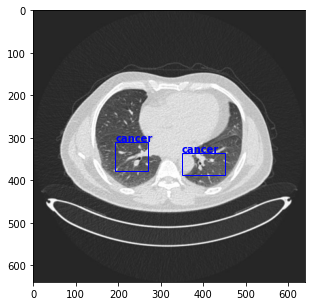

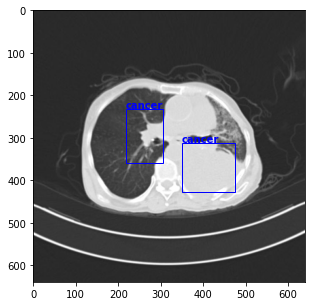

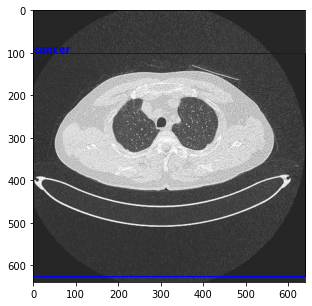

In [18]:
dataset = CraterDataset('yolo/valid', get_transform(train=True))
# Prints an example of image with annotations
for i in random.sample(range(1, 100), 3):
    img, target = dataset[i]
    plot_img_bbox(img, target)

In [20]:
num_epochs = 2

# our dataset has two classes only - background and crater
num_classes = 3
# use our dataset and defined transformations
dataset = CraterDataset('yolo/train', get_transform(train=True))
dataset_test = CraterDataset('yolo/valid', get_transform(train=False))

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=8, shuffle=True, num_workers=0,
    collate_fn=utils.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

# get the model using our helper function
model = get_model_bbox(num_classes)

'''
Use this to reset all trainable weights
model.apply(reset_weights)
'''

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,  # Feel free to play with values
                            momentum=0.9, weight_decay=0)

# Defining learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=20,
                                                gamma=0.2)


result_mAP = []
best_epoch = None

# Let's train!
for epoch in range(num_epochs):


    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    results =  evaluate(model, data_loader_test, device=device)
    # saves results of mAP @ IoU = 0.5
    result_mAP.append(results.coco_eval['bbox'].stats[1])
    #save the best model so far
    if result_mAP[-1] == max(result_mAP):
        best_save_path = os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{epoch}.pth')
        torch.save(model.state_dict(), best_save_path)
        best_epoch = int(epoch)
        print(f'\n\nmodel from epoch number {epoch} saved!\n result is {max(result_mAP)}\n\n')

# Saving the last model
save_path = os.path.join(f'noaug_sgd_2batch-lastepoch{num_epochs-1}.pth')
torch.save(model.state_dict(), save_path)
print(f'model from last epoch(no.{num_epochs-1}) saved')

Epoch: [0]  [ 0/53]  eta: 0:19:49  lr: 0.000950  loss: 1.8314 (1.8314)  classification: 1.3019 (1.3019)  bbox_regression: 0.5295 (0.5295)  time: 22.4505  data: 0.0700
Epoch: [0]  [50/53]  eta: 0:01:07  lr: 0.005000  loss: 0.6490 (0.8113)  classification: 0.3425 (0.4752)  bbox_regression: 0.3109 (0.3361)  time: 22.2506  data: 0.0899
Epoch: [0]  [52/53]  eta: 0:00:22  lr: 0.005000  loss: 0.5934 (0.8050)  classification: 0.3226 (0.4697)  bbox_regression: 0.3052 (0.3354)  time: 21.8658  data: 0.0871
Epoch: [0] Total time: 0:19:39 (22.2635 s / it)
creating index...
index created!
Test:  [  0/121]  eta: 0:19:42  model_time: 9.7567 (9.7567)  evaluator_time: 0.0070 (0.0070)  time: 9.7717  data: 0.0080
Test:  [100/121]  eta: 0:03:17  model_time: 9.5118 (9.3759)  evaluator_time: 0.0020 (0.0076)  time: 9.2057  data: 0.0107
Test:  [120/121]  eta: 0:00:09  model_time: 9.6497 (9.3615)  evaluator_time: 0.0030 (0.0070)  time: 9.3057  data: 0.0128
Test: Total time: 0:18:55 (9.3806 s / it)
Averaged stat

In [25]:
p_retina = 0.427
r_retina = 0.653
mAP_retina = 0.605

In [28]:
storeResults('RetinaNet',p_retina,r_retina,mAP_retina)

In [21]:
dataset_test = CraterDataset('yolo/valid', get_transform(train=False))

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    collate_fn=utils.collate_fn)

model = get_model_bbox(num_classes)

# load model to evaluate
model.load_state_dict(torch.load(os.path.join(f'bestmodel_noaug_sgd(wd=0)_8batch-epoch{best_epoch}.pth'),map_location=device))
model.to(device)
evaluate(model, data_loader_test, device=device)

creating index...
index created!
Test:  [  0/121]  eta: 0:19:18  model_time: 9.5382 (9.5382)  evaluator_time: 0.0320 (0.0320)  time: 9.5782  data: 0.0080
Test:  [100/121]  eta: 0:03:17  model_time: 9.6083 (9.3665)  evaluator_time: 0.0040 (0.0080)  time: 9.4066  data: 0.0113
Test:  [120/121]  eta: 0:00:09  model_time: 9.3867 (9.3470)  evaluator_time: 0.0040 (0.0073)  time: 9.2644  data: 0.0119
Test: Total time: 0:18:53 (9.3659 s / it)
Averaged stats: model_time: 9.3867 (9.3470)  evaluator_time: 0.0040 (0.0073)
Accumulating evaluation results...
DONE (t=0.08s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.272
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.605
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.173
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.130
 Average Precisio

# Comparison

In [38]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,

                       'Precision': precision,
                       'Recall'   : recall,
                       'mAP' : mAP,


                      })

In [39]:
result

,ML Model,Precision,Recall,mAP
0,FasterRCNN,0.382,0.606,0.463
1,RetinaNet,0.427,0.653,0.605
2,YoloV5,0.940,0.990,0.990
3,YoloV8,0.645,0.663,0.628


# Graph

In [40]:
import numpy as np

In [41]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Precision

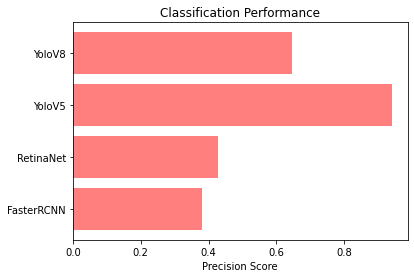

In [42]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

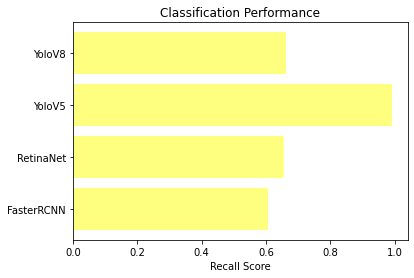

In [43]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# mAP

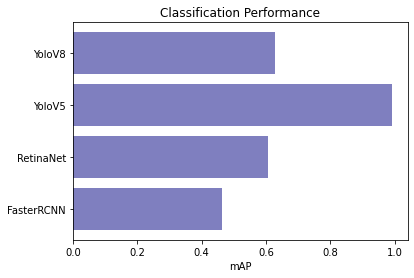

In [44]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, mAP, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('mAP')
plt2.title('Classification Performance')
plt2.show()